# Underfitting Model

by Niklas Vogel and Kevin Stupar

## Setup
This notebook creates an underfitting model and evaluates it.

Before executing this please make sure you did download and extract the data using an unzip tool optimized for your OS (`unzip` in WSL could take a long time)
The Download can be done using `setup.sh`

## Data Credit
TODO

# Load the data and split it

In [6]:
from helper import get_data, plot_accuracy_and_loss, plot_confusion_matrix, plot_samples, plot_number_per_class, calculate_predictions, plot_scores
from keras import layers, models

image_size = (64, 64)

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  9043
Number of validation images:  2260
Number of testing images:  4845
Class names:  ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

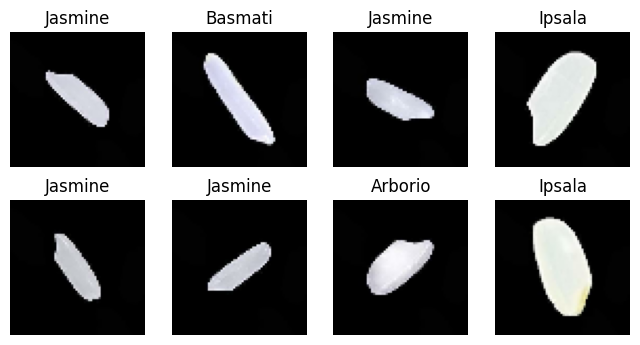

In [7]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 4000 images, except for Karacadag, which only has 150 images.
This should lead to a worse performance of this class.

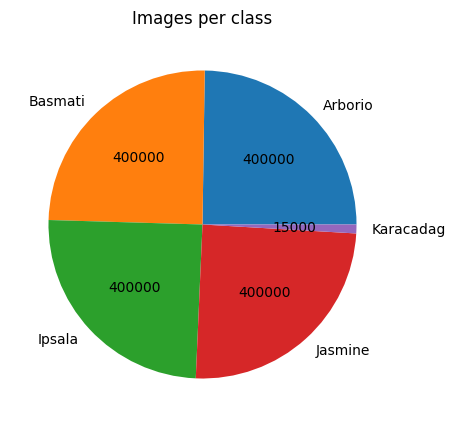

In [8]:
plot_number_per_class(all_images, label_names)

In [9]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Rescaling(1./255),
    layers.Conv2D(2, (3, 3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 2)      │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551 (2.15 KB)

 Trainable params: 551 (2.15 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, epochs=30, validation_data=validation_images)

Epoch 1/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6342 - loss: 0.9488 - val_accuracy: 0.8332 - val_loss: 0.5039
Epoch 2/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9062 - loss: 0.3386 - val_accuracy: 0.9522 - val_loss: 0.2132
Epoch 3/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9518 - loss: 0.1996 - val_accuracy: 0.9615 - val_loss: 0.1578
Epoch 4/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9597 - loss: 0.1546 - val_accuracy: 0.9637 - val_loss: 0.1323
Epoch 5/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9626 - loss: 0.1354 - val_accuracy: 0.9664 - val_loss: 0.1337
Epoch 6/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9621 - loss: 0.1266 - val_accuracy: 0.9655 - val_loss: 0.1182
Epoch 7/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9649 - loss: 0.1148 - val_accuracy: 0.9637 - val_loss: 0.1104
Epoch 8/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9631 - loss: 0.1070 - val_accu

# Evaluating the model

Using a few plots we can see, that the model is underfitting.
Note that the loss is on a log scale to be able to interpret the results better.

In [19]:
true, pred = calculate_predictions(model, test_images)

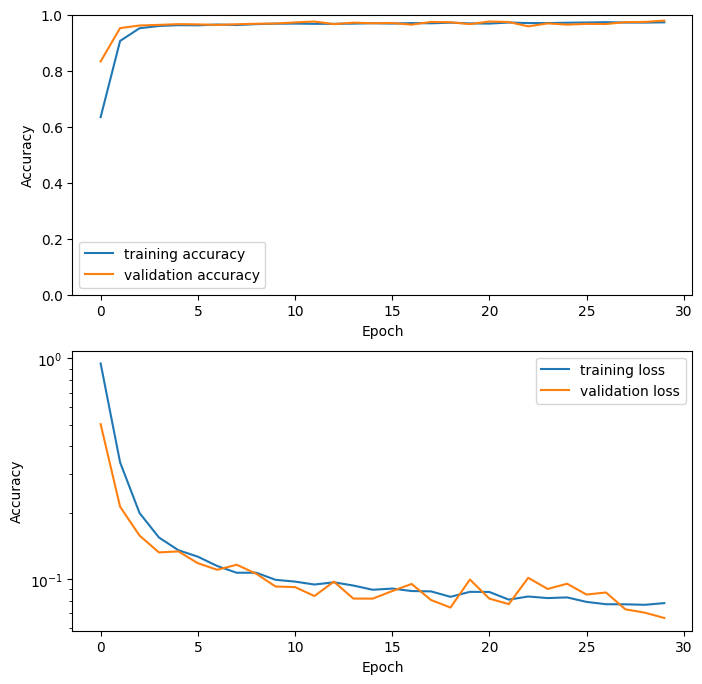

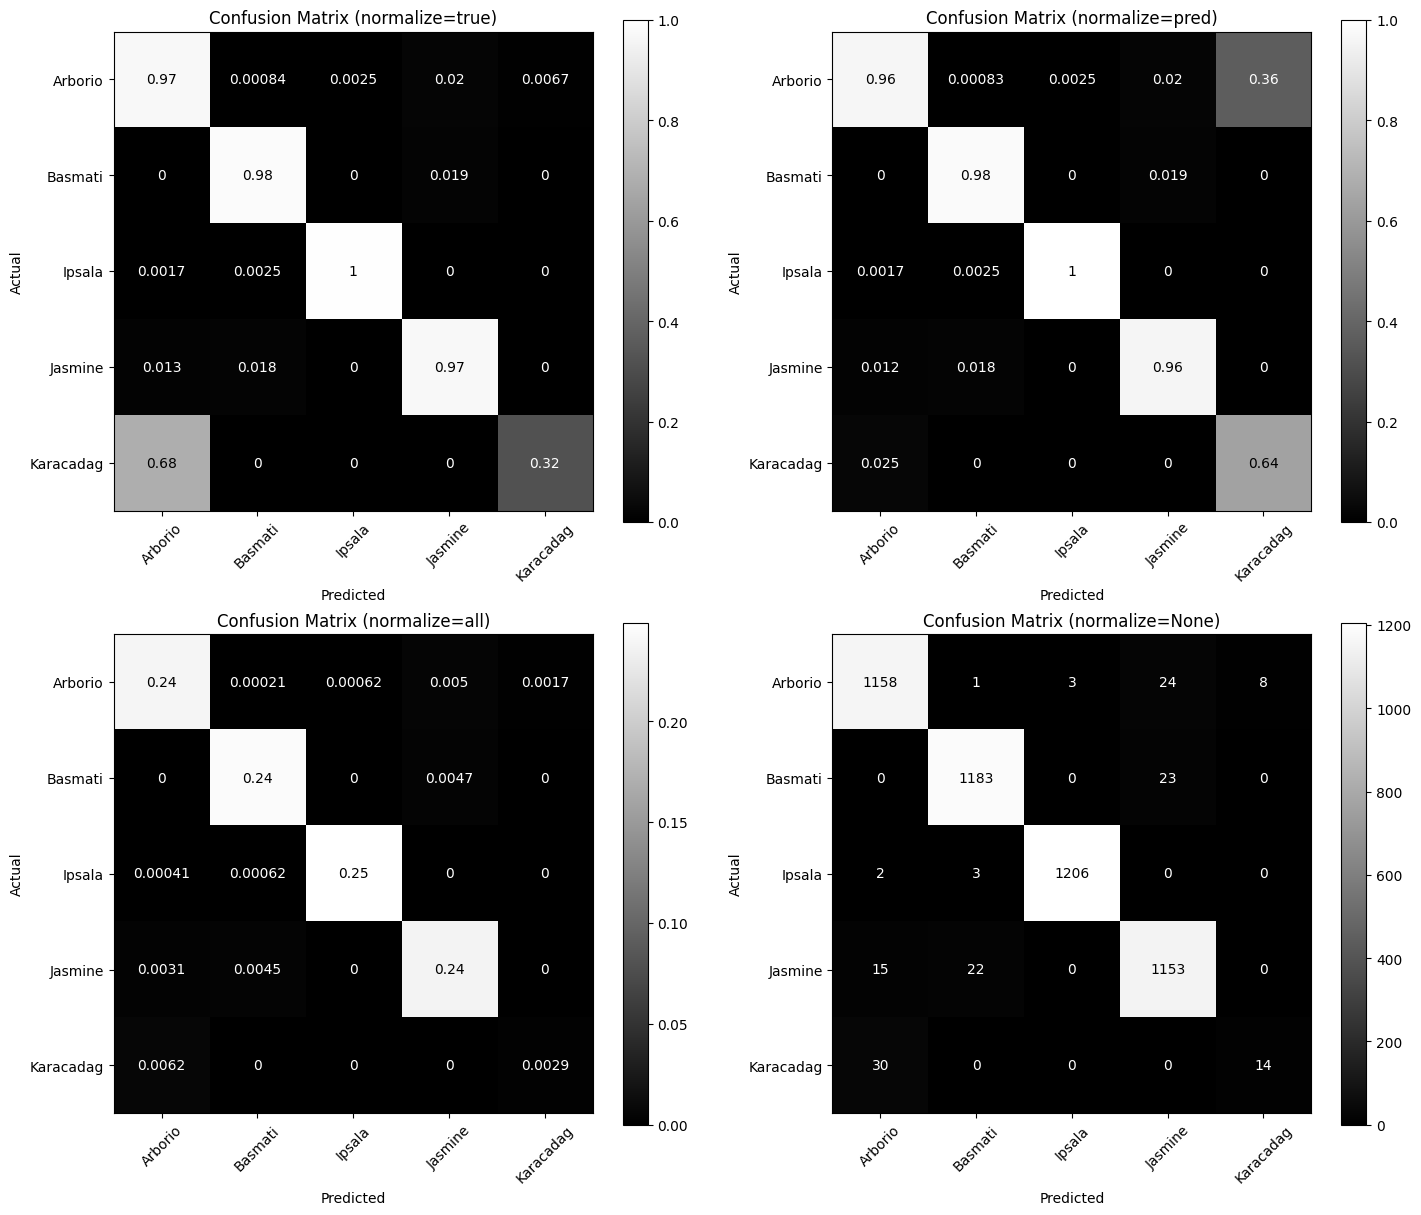

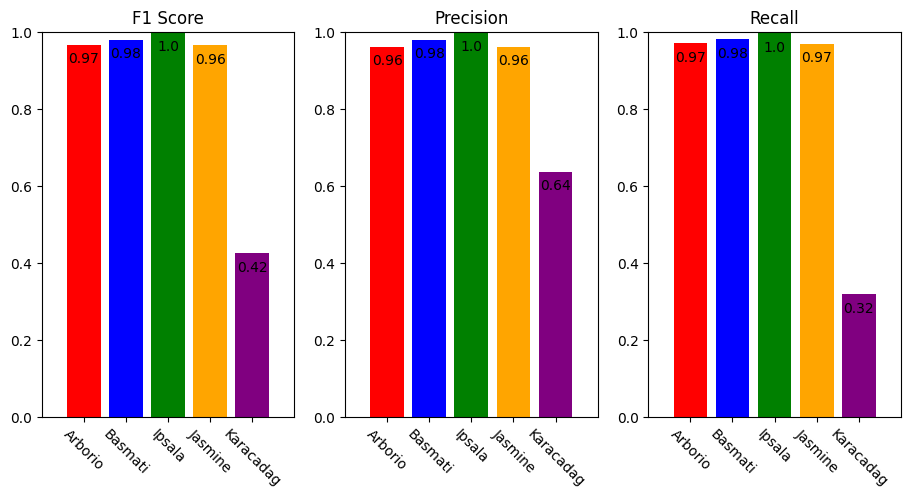

In [34]:
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])

plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Discussion

The model has an accuracy of 0.97 which is very high considering it has only 551 trainable parameters. This is probably due to the amount of very good images with nearly no noise.
This theorie gets backed up when we look at the training metrics. The classes with 4k images have nearly perfect scores. But the metrics of the class (Karacadag) with only 150 images are much worse.
Karacadag having a bad F1 score just tells us that the dataset is unbalanced so thats not further surprising.
Karacadag having a not to bad precision is a bit surprising but explained when we look at the bad recall of Karacadag. The racall tells us that only in 32% of Karacadag even get classified as such. This shows the underfitting of the model with having high bias towards the other classes. And this also explains the high precision as the model only predicts Karacadag in very confidant cases.
The same can be see quite nicely in the first confusion matrix. Most Karacadag get calssified as ....

